In [1]:
%pip install kaleido imageio

zsh:1: no matches found: imageio[ffmpeg]
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install uproot
%pip install plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 2.3 MB/s  0:00:003.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.8/543.8 kB 3.1 MB/s  0:00:00? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 3.8 MB/s  0:00:003.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [uproot]━━━━ 5/6 [uproot]awkward]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Users/daisykalra/.local/pipx/venvs/notebook/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
#%matplotlib notebook  # or %matplotlib widget

import uproot
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # optional in newer matplotlib

import plotly.graph_objects as go

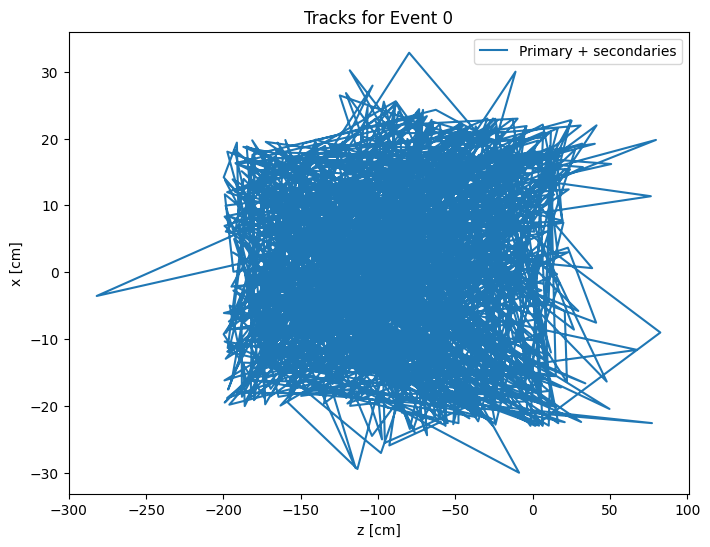

In [24]:
file = uproot.open("/Users/daisykalra/geant4-neutrino/newGeant4DockerImage/electron.root")
tree = file["tree"]   # not "Events"

x = tree["x"].array()
y = tree["y"].array()
z = tree["z"].array()
nSteps = tree["nSteps"].array()

# For simplicity, look at first event
nsteps_first_event = nSteps[10]
x_ev = x[:nsteps_first_event]
y_ev = y[:nsteps_first_event]
z_ev = z[:nsteps_first_event]

plt.figure(figsize=(8,6))
plt.plot(z_ev, x_ev, label="Primary + secondaries")
plt.xlabel("z [cm]")
plt.ylabel("x [cm]")
plt.title("Tracks for Event 0")
plt.legend()
plt.show()

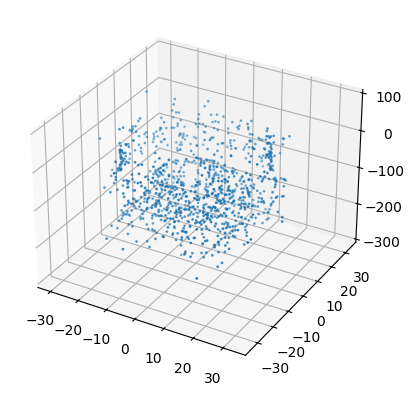

In [25]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x_ev, y_ev, z_ev, s=1)
plt.show()

In [26]:
import plotly.io as pio
pio.renderers.default = "iframe"

fig = go.Figure(data=[go.Scatter3d(
    x=x_ev,
    y=y_ev,
    z=z_ev,
    mode='markers',
    marker=dict(size=2, color=z, colorscale='Viridis')
)])

fig.update_layout(scene=dict(
                    xaxis_title='X',
                    yaxis_title='Y',
                    zaxis_title='Z'),
                  width=800,
                  height=600)

fig.show()